# Phase-2 bare-bones explorer

Single diffusion time (`m = 1`), one parameter coordinate, no downstream
restrictions unless you switch them on.

1. **Setup** - constants and functions.
2. **Choose and compute** - the knobs, then load / build.
3. **View** - tables and plots.

All acquisition limits (`G_MAX`, `TRUST_FLOOR`, `RICIAN_MIN`, `AVERAGES`) live in
section 2 and default to **off**, and turning them off really does expose every
stored column: the Phase-1 substrate spans the full `(delta, Delta, b)` grid and
section 1 asserts it. See `docs/fisher_domain_audit.md`.

## 1. Setup

In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO       = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
ARTIFACT   = REPO / "data/libraries/madi_dense_universal_remediated.npz"
PHASE1_DIR = Path("/home/jaden/madi_fisher_runs/full_domain/phase1")
CACHE_DIR  = Path("/home/jaden/madi_fisher_runs/full_domain/cache")

sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))
from madi.fisher_crlb import (PARAMETER_ORDER, canonical_grid, column_arrays, fisher_diagnostics,
                              fisher_matrix, gradient_strength_t_per_m, pack_fisher,
                              packed_amplitude_marginal, packed_inverse_diagonal, read_column_domain,
                              te_noise_sigma, unpack_fisher)
from run_fisher_phase2 import build_node_table, transposed_view

np.set_printoptions(precision=5, linewidth=140)

In [2]:
# ---- load: library labels, node table, column-major signal caches -----------
with np.load(ARTIFACT, allow_pickle=False) as d:
    PAIR_D  = np.asarray(d["pair_deltas"], float)      # small delta, ms
    PAIR_DD = np.asarray(d["pair_Deltas"], float)      # big Delta, ms
    B_VALUES = np.asarray(d["b_values"], float)        # s/mm^2
    N_B = int(d["n_b"])
    TABLE = build_node_table(PHASE1_DIR, d)            # nodes with all three k=1 stencils

VECTORS  = transposed_view(CACHE_DIR, "vectors")           # (column, entry)  S/S0
VARIANCE = transposed_view(CACHE_DIR, "signal_variance")   # (column, entry)  var of ensemble MEANS
N_ENS    = int(np.load(CACHE_DIR / "ensemble_means_subset.npy", mmap_mode="r").shape[1])

# The Phase-1 substrate spans every stored column, and this asserts it rather
# than trusting it: before 2026-09-06 it did not, so setting G_MAX = inf below
# could not recover the gradient-infeasible columns.  See docs/fisher_domain_audit.md.
DOMAIN   = read_column_domain(json.loads((PHASE1_DIR / "phase1_manifest.json").read_text()))
print(DOMAIN.banner())
assert DOMAIN.is_complete, "this notebook reads the model, so it needs the unrestricted substrate"
SELECTED = np.asarray(DOMAIN.column_indices, int)
POSITION = DOMAIN.position_of

RHOS, VS, KIOS, _ = canonical_grid()
NODE_RHO, NODE_V, NODE_KIO = TABLE["rho"], TABLE["V"], TABLE["kio"]
N_NODES = len(TABLE["nodes"])
AXES = ("rho", "V", "k_io")

D_COL, DD_COL, B_COL = column_arrays(PAIR_D, PAIR_DD, B_VALUES)
GRAD_COL = gradient_strength_t_per_m(D_COL, DD_COL, B_COL)   # T/m per full column

print(f"{N_NODES} nodes | {len(PAIR_D)} timing pairs x {N_B} b | n_ensembles={N_ENS}")
print(f"rho {RHOS.min():.3g}..{RHOS.max():.3g} cells/uL | V {VS.min():.3g}..{VS.max():.3g} pL "
      f"| k_io {KIOS.min():g}..{KIOS.max():g} 1/s")

COLUMN DOMAIN COMPLETE — all 31125 stored (delta, Delta, b) columns
11417 nodes | 1245 timing pairs x 25 b | n_ensembles=40
rho 1e+04..1e+07 cells/uL | V 0.01..200 pL | k_io 0..130 1/s


In [3]:
# ---- functions -------------------------------------------------------------

def node_at(rho, V, k_io):
    """Nearest node. rho/V matched in log space (both grids span decades)."""
    c = ((np.log(NODE_RHO) - math.log(rho)) / np.ptp(np.log(NODE_RHO))) ** 2 \
      + ((np.log(NODE_V) - math.log(V)) / np.ptp(np.log(NODE_V))) ** 2 \
      + ((NODE_KIO - k_io) / np.ptp(NODE_KIO)) ** 2
    return int(np.argmin(c))


def pair_at(delta, Delta):
    """Nearest stored timing pair index."""
    return int(np.argmin((PAIR_D - delta) ** 2 + (PAIR_DD - Delta) ** 2))


def columns_at(pair, b_min=0.0, b_max=np.inf, g_max=np.inf, drop_b0=True):
    """Cache positions for one timing pair, filtered only by what you ask for."""
    full = pair * N_B + np.arange(N_B)
    keep = (POSITION[full] >= 0) & (B_COL[full] >= b_min) & (B_COL[full] <= b_max) \
         & (GRAD_COL[full] <= g_max)
    if drop_b0:
        keep &= B_COL[full] > 0          # S(0)=1 for every entry, so J == 0 there
    return POSITION[full[keep]]


def analyze(node, pair, columns, averages=1.0, snr=50.0, T2=80.0, t_epi=0.0,
            trust_floor=0.0, rician_min=0.0, debias=True, n0_eff=None, kio_floor=1.0):
    """Everything at one node for one single-Delta acquisition."""
    S    = np.asarray(VECTORS[columns],  np.float64)   # (n_col, entries)
    Svar = np.asarray(VARIANCE[columns], np.float64)
    step = np.asarray([TABLE[f"step_{a}"][node] for a in AXES])   # dlogrho, dlogV, dk_io

    S_c  = S[:, TABLE["centre"][node]]
    Sm   = np.stack([S[:,    TABLE[f"minus_{a}"][node]] for a in AXES], -1)
    Sp   = np.stack([S[:,    TABLE[f"plus_{a}"][node]]  for a in AXES], -1)
    Vm   = np.stack([Svar[:, TABLE[f"minus_{a}"][node]] for a in AXES], -1)
    Vp   = np.stack([Svar[:, TABLE[f"plus_{a}"][node]]  for a in AXES], -1)

    J     = (Sp - Sm) / step                              # dS/d(log rho, log V, k_io)
    var_J = (Vp + Vm) / (N_ENS * step ** 2)               # endpoint-only; OVERSTATES (drops CRN cov)
    beta  = np.divide(var_J, J ** 2, out=np.full_like(var_J, np.inf), where=J != 0)

    sigma_1 = float(te_noise_sigma(PAIR_D[pair], PAIR_DD[pair], sigma0=1/snr, T2_ms=T2, t_epi_ms=t_epi))
    sigma   = sigma_1 / math.sqrt(averages)
    keep    = (S_c >= trust_floor) & (S_c >= rician_min * sigma)

    F   = fisher_matrix(J, sigma, var_J if debias else None, keep)
    F_u = fisher_matrix(J, sigma, None, keep)
    if n0_eff is not None:                                # marginalise unknown S0
        u = np.where(keep, 1/sigma**2, 0.0)
        F = unpack_fisher(packed_amplitude_marginal(
            pack_fisher(F), (J * (u * S_c)[:, None]).sum(0), float((u * S_c**2).sum()),
            float(n0_eff) / sigma_1**2))

    kio_ref = max(float(NODE_KIO[node]), kio_floor)
    dg      = fisher_diagnostics(F, kio_ref)
    ok      = bool(packed_inverse_diagonal(pack_fisher(F))[2])
    crlb    = dg["crlb"]  if ok else np.full(3, np.inf)   # not PD -> no bound (0.0 would lie)
    kappa   = dg["kappa"] if ok else np.full(3, np.inf)
    return dict(node=node, pair=pair, columns=columns, b=B_COL[SELECTED[columns]],
                gradient=GRAD_COL[SELECTED[columns]], step=step, sigma_1=sigma_1, sigma=sigma,
                S=S_c, J=J, var_J=var_J, beta=beta, keep=keep, F=F, F_undebiased=F_u,
                Finv=dg["Finv"], crlb=crlb, relative_crlb=np.array([crlb[0], crlb[1], crlb[2]/kio_ref]),
                kappa=kappa, identifiable=ok, eig=dg["F_tilde_eigenvalues"],
                eigvec=dg["F_tilde_eigenvectors"], kio_ref=kio_ref)


_P1 = {}
def r_trunc(node):
    """|J_k1 - Richardson|/|J_k1| over all selected columns. rho and V only.

    k_io was pre-registered at k=1 alone, so it has no k=2 companion.  Returns
    None for an axis this node has no k1/k2 overlap on.
    """
    out = {}
    for axis in ("rho", "V"):
        key = tuple(int(v) for v in TABLE["nodes"][node])
        if axis not in _P1:
            s = np.load(PHASE1_DIR / f"samples_Richardson_{axis}_k1_k2.npy")
            _P1[axis] = {tuple(int(v) for v in r): i for i, r in enumerate(s)}
        row = _P1[axis].get(key)
        if row is None:
            out[axis] = None; continue
        J1  = np.asarray(np.load(PHASE1_DIR / f"J_{axis}_k1.npy", mmap_mode="r")
                         [int(TABLE["phase1_rows"][axis][node])], np.float64)
        imp = np.asarray(np.load(PHASE1_DIR / f"Richardson_{axis}_k1_k2.npy", mmap_mode="r")[row], np.float64)
        with np.errstate(divide="ignore", invalid="ignore"):
            out[axis] = np.where(J1 != 0, np.abs(J1 - imp) / np.abs(J1), np.nan)
    out["k_io"] = None
    return out


# ---- arbitrary multi-timing acquisition helpers ----------------------------
def acquisition_columns(acquisitions, g_max=np.inf, drop_b0=True, b_tol=1e-6):
    """Resolve [(delta_ms, Delta_ms, [b...]), ...] into stored cache columns.

    Each timing row may use a different set of b-values. Requested timings and
    b-values must exist in the stored library (within b_tol for b).
    """
    cols, pairs, requested_b = [], [], []
    for delta, Delta, bvals in acquisitions:
        p = pair_at(float(delta), float(Delta))
        if not (np.isclose(PAIR_D[p], delta) and np.isclose(PAIR_DD[p], Delta)):
            raise ValueError(f"timing ({delta}, {Delta}) ms not stored; nearest is "
                             f"({PAIR_D[p]}, {PAIR_DD[p]}) ms")
        for b in bvals:
            j = int(np.argmin(np.abs(B_VALUES - float(b))))
            if abs(B_VALUES[j] - float(b)) > b_tol:
                raise ValueError(f"b={b} not stored; nearest is {B_VALUES[j]}")
            full = p * N_B + j
            if POSITION[full] < 0:
                raise ValueError(f"column ({delta}, {Delta}, {b}) is not in cache domain")
            if GRAD_COL[full] > g_max or (drop_b0 and B_COL[full] <= 0):
                continue
            cols.append(int(POSITION[full])); pairs.append(p); requested_b.append(float(b))
    return np.asarray(cols, int), np.asarray(pairs, int), np.asarray(requested_b, float)


def analyze_acquisition(node, acquisitions, averages=1.0, snr=50.0, T2=80.0, t_epi=0.0,
                        trust_floor=0.0, rician_min=0.0, debias=True, n0_eff=None,
                        kio_floor=1.0, g_max=np.inf, drop_b0=True):
    """Fisher/CRLB for an arbitrary collection of (delta, Delta, b) columns."""
    columns, pairs, _ = acquisition_columns(acquisitions, g_max, drop_b0)
    if len(columns) == 0:
        raise ValueError("acquisition contains no usable columns")

    S    = np.asarray(VECTORS[columns], np.float64)
    Svar = np.asarray(VARIANCE[columns], np.float64)
    step = np.asarray([TABLE[f"step_{a}"][node] for a in AXES])
    S_c  = S[:, TABLE["centre"][node]]
    Sm   = np.stack([S[:, TABLE[f"minus_{a}"][node]] for a in AXES], -1)
    Sp   = np.stack([S[:, TABLE[f"plus_{a}"][node]]  for a in AXES], -1)
    Vm   = np.stack([Svar[:, TABLE[f"minus_{a}"][node]] for a in AXES], -1)
    Vp   = np.stack([Svar[:, TABLE[f"plus_{a}"][node]]  for a in AXES], -1)
    J     = (Sp - Sm) / step
    var_J = (Vp + Vm) / (N_ENS * step ** 2)
    beta  = np.divide(var_J, J**2, out=np.full_like(var_J, np.inf), where=J != 0)

    sigma_1 = np.array([te_noise_sigma(PAIR_D[p], PAIR_DD[p], sigma0=1/snr,
                                       T2_ms=T2, t_epi_ms=t_epi) for p in pairs], float)
    sigma = sigma_1 / math.sqrt(averages)
    keep = (S_c >= trust_floor) & (S_c >= rician_min * sigma)
    w = np.where(keep, 1.0 / sigma**2, 0.0)

    # Independent acquisition columns add information. Debias removes the
    # endpoint Monte-Carlo derivative variance from each Fisher diagonal.
    F_u = J.T @ (w[:, None] * J)
    F = F_u.copy()
    if debias:
        F[np.diag_indices(3)] -= (w[:, None] * var_J).sum(axis=0)

    if n0_eff is not None:
        cross = (J * (w * S_c)[:, None]).sum(axis=0)
        amp_info = float((w * S_c**2).sum())
        # n0_eff is expressed as effective b=0 measurements; with multiple
        # timings use the baseline sigma0=1/snr (no TE attenuation penalty).
        amp_prior = float(n0_eff) * snr**2
        F -= np.outer(cross, cross) / (amp_info + amp_prior)

    kio_ref = max(float(NODE_KIO[node]), kio_floor)
    dg = fisher_diagnostics(F, kio_ref)
    ok = bool(packed_inverse_diagonal(pack_fisher(F))[2])
    crlb = dg["crlb"] if ok else np.full(3, np.inf)
    kappa = dg["kappa"] if ok else np.full(3, np.inf)
    full = SELECTED[columns]
    return dict(node=node, pairs=pairs, columns=columns, b=B_COL[full],
                delta=D_COL[full], Delta=DD_COL[full], gradient=GRAD_COL[full],
                step=step, sigma_1=sigma_1, sigma=sigma, S=S_c, J=J, var_J=var_J,
                beta=beta, keep=keep, F=F, F_undebiased=F_u, Finv=dg["Finv"],
                crlb=crlb, relative_crlb=np.array([crlb[0], crlb[1], crlb[2]/kio_ref]),
                kappa=kappa, identifiable=ok, eig=dg["F_tilde_eigenvalues"],
                eigvec=dg["F_tilde_eigenvectors"], kio_ref=kio_ref)


## 2. Choose and compute

Everything you would want to change is here. All limits default to **off**:
`G_MAX = inf`, `TRUST_FLOOR = 0`, `RICIAN_MIN = 0`, `AVERAGES = 1`.

In [29]:
# ---- parameter coordinate --------------------------------------------------
RHO   = 2.5e5     # cells/uL
V     = 4.0       # pL
K_IO  = 20.0      # 1/s

# ---- acquisition matrix ----------------------------------------------------
# One row = (small delta [ms], big Delta [ms], [b-values in s/mm^2]).
# Rows can have different b-value lists. For the original single-timing test,
# leave only the first row.
# ACQUISITIONS = [
#     (4.0, 15.0, [1000, 2500, 4000, 6000]),
#     (4.0, 25.0, [1000, 2500, 4000, 6000]),
#     (4.0, 30.0, [1000, 2500, 4000, 6000]),
#     (4.0, 40.0, [1000, 2500, 4000, 6000]),
# ]

ACQUISITIONS = [
    (4.0, 15.0, [1000, 2500, 4000, 6000]),
    (8.0, 25.0, [1000, 2500, 4000, 6000]),
    (4.0, 40.0, [1000, 2500, 4000, 6000]),
    (8.0, 40.0, [1000, 2500, 4000, 6000]),
]

G_MAX        = np.inf
DROP_B0      = True
SNR, T2_MS, T_EPI_MS = 50.0, 80.0, 0.0
AVERAGES     = 1.0
TRUST_FLOOR  = 0.0
RICIAN_MIN   = 0.0
DEBIAS       = True
N0_EFF       = None

NODE = node_at(RHO, V, K_IO)
R = analyze_acquisition(NODE, ACQUISITIONS, AVERAGES, SNR, T2_MS, T_EPI_MS,
                        TRUST_FLOOR, RICIAN_MIN, DEBIAS, N0_EFF,
                        g_max=G_MAX, drop_b0=DROP_B0)
RT = r_trunc(NODE)
COLS = R["columns"]

print(f"node {NODE}: rho={NODE_RHO[NODE]:.4g} cells/uL  V={NODE_V[NODE]:.4g} pL  "
      f"k_io={NODE_KIO[NODE]:.4g} 1/s  v_i={NODE_RHO[NODE]*NODE_V[NODE]*1e-6:.4f}")
print(f"{len(COLS)} acquisition columns, {int(R['keep'].sum())} kept by masks")
for p in np.unique(R["pairs"]):
    m = R["pairs"] == p
    print(f"  pair {p}: delta={PAIR_D[p]:.1f}, Delta={PAIR_DD[p]:.1f} ms | "
          f"b={R['b'][m].astype(int).tolist()} | sigma={R['sigma'][m][0]:.5f}")
print(f"steps: dlog(rho)={R['step'][0]:.5f}  dlog(V)={R['step'][1]:.5f}  dk_io={R['step'][2]:.5f}")


node 5311: rho=2.404e+05 cells/uL  V=3.357 pL  k_io=20 1/s  v_i=0.8071
16 acquisition columns, 16 kept by masks
  pair 176: delta=4.0, Delta=15.0 ms | b=[1000, 2500, 4000, 6000] | sigma=0.02536
  pair 201: delta=4.0, Delta=40.0 ms | b=[1000, 2500, 4000, 6000] | sigma=0.03467
  pair 388: delta=8.0, Delta=25.0 ms | b=[1000, 2500, 4000, 6000] | sigma=0.03021
  pair 403: delta=8.0, Delta=40.0 ms | b=[1000, 2500, 4000, 6000] | sigma=0.03644
steps: dlog(rho)=0.21979  dlog(V)=0.31458  dk_io=2.00000


## 3. View

In [31]:
# ---- per-column table ------------------------------------------------------
hdr = f"{'delta':>7}{'Delta':>7}{'b':>7}{'G':>7}{'S':>9}{'keep':>6} |{'J_logrho':>11}{'J_logV':>11}{'J_kio':>12} |{'beta_rho':>10}{'beta_V':>10}{'beta_kio':>10}"
print(hdr); print("-" * len(hdr))
for i, c in enumerate(COLS):
    print(f"{R['delta'][i]:7.1f}{R['Delta'][i]:7.1f}{R['b'][i]:7.0f}{R['gradient'][i]:7.3f}{R['S'][i]:9.5f}{str(bool(R['keep'][i])):>6} |"
          f"{R['J'][i,0]:11.5f}{R['J'][i,1]:11.5f}{R['J'][i,2]:12.3e} |"
          f"{R['beta'][i,0]:10.2e}{R['beta'][i,1]:10.2e}{R['beta'][i,2]:10.2e}")


  delta  Delta      b      G        S  keep |   J_logrho     J_logV       J_kio |  beta_rho    beta_V  beta_kio
---------------------------------------------------------------------------------------------------------------
    4.0   15.0   1000  0.253  0.26783  True |    0.18198    0.07207  -2.419e-03 |  1.74e-04  4.49e-04  1.31e-02
    4.0   15.0   2500  0.400  0.05568  True |    0.05319    0.00706  -1.095e-03 |  1.19e-03  2.32e-02  2.48e-02
    4.0   15.0   4000  0.506  0.01983  True |    0.01938    0.00250  -5.131e-04 |  8.47e-03  2.37e-01  1.17e-01
    4.0   15.0   6000  0.619  0.00925  True |    0.01221    0.00214  -2.463e-04 |  2.51e-02  3.62e-01  5.86e-01
    8.0   25.0   1000  0.099  0.33736  True |    0.29138    0.15342  -4.020e-03 |  1.09e-04  1.55e-04  5.35e-03
    8.0   25.0   2500  0.156  0.09773  True |    0.12918    0.03274  -2.314e-03 |  4.70e-04  2.93e-03  1.35e-02
    8.0   25.0   4000  0.198  0.03915  True |    0.05715    0.00423  -1.156e-03 |  1.76e-03  1.22e-01  3

In [32]:
# ---- Fisher matrix and bounds ----------------------------------------------
F = R["F"]

print("F (debias=%s, n0_eff=%s)" % (DEBIAS, N0_EFF))
print(f"{'':>9}" + "".join(f"{n:>16}" for n in PARAMETER_ORDER))
for i, n in enumerate(PARAMETER_ORDER):
    print(f"{n:>9}" + "".join(f"{F[i,j]:16.6g}" for j in range(3)))

shift = np.diag(R["F_undebiased"]) - np.diag(F)
print(f"\ndebias removed from diagonal : {shift}")
print(f"  as a fraction of undebiased: "
      f"{shift / np.diag(R['F_undebiased'])}")


# ---- Rank / singularity diagnostics ----------------------------------------
rank = np.linalg.matrix_rank(F)
det = np.linalg.det(F)
cond = np.linalg.cond(F)

# Fisher matrix should be symmetric, so eigvalsh is preferred
eigvals = np.linalg.eigvalsh(F)

# Singular values are another robust way to inspect near-singularity
singular_values = np.linalg.svd(F, compute_uv=False)

print("\n--- Fisher matrix diagnostics ---")
print(f"shape                 : {F.shape}")
print(f"rank                  : {rank} / {F.shape[0]}")
print(f"full rank             : {rank == F.shape[0]}")
print(f"det(F)                : {det:.6g}")
print(f"condition number      : {cond:.6g}")

print(f"eigenvalues           : {eigvals}")
print(f"smallest eigenvalue   : {eigvals.min():.6g}")
print(f"largest eigenvalue    : {eigvals.max():.6g}")

print(f"singular values       : {singular_values}")
print(f"smallest singular val : {singular_values.min():.6g}")

print(f"positive definite     : {np.all(eigvals > 0)}")

if rank < F.shape[0]:
    print("WARNING: F is rank deficient -> not invertible.")
elif not np.all(eigvals > 0):
    print("WARNING: F is full rank but indefinite -> invalid for finite CRLB.")
elif cond > 1e12:
    print("WARNING: F is full rank but extremely ill-conditioned.")
elif cond > 1e8:
    print("WARNING: F is poorly conditioned; CRLB may be numerically unstable.")
else:
    print("F appears numerically invertible.")


# ---- CRLB ------------------------------------------------------------------
print(f"\n{'':>9}{'CRLB':>16}{'rel CRLB':>16}{'kappa':>12}")
for i, n in enumerate(PARAMETER_ORDER):
    print(
        f"{n:>9}"
        f"{R['crlb'][i]:16.6g}"
        f"{R['relative_crlb'][i]:16.6g}"
        f"{R['kappa'][i]:12.4g}"
    )

print(f"\nidentifiable (F positive definite): {R['identifiable']}")

if not R["identifiable"]:
    print(
        "  -> no finite bound exists here; "
        "CRLB/kappa are reported as inf, not 0."
    )


# ---- Scaled-F eigen diagnostics --------------------------------------------
print(f"\neigenvalues of k_io-scaled F: {R['eig']}")

scaled_cond = (R["eig"].max() / R["eig"].min()) if R["eig"].min() > 0 else np.inf
print(f"condition number (scaled F): {scaled_cond:.4g}")

print(
    "smallest-eigenvalue direction "
    "(log_rho, log_V, k_io*): "
    f"{R['eigvec'][:, 0]}"
)

F (debias=True, n0_eff=None)
                  log_rho           log_V            k_io
  log_rho          445.84         231.321        -7.12802
    log_V         231.321         128.371        -3.60776
     k_io        -7.12802        -3.60776        0.116403

debias removed from diagonal : [0.09473 0.0403  0.00108]
  as a fraction of undebiased: [0.00021 0.00031 0.00921]

--- Fisher matrix diagnostics ---
shape                 : (3, 3)
rank                  : 3 / 3
full rank             : True
det(F)                : 5.43463
condition number      : 389241
eigenvalues           : [1.45864e-03 6.56225e+00 5.67764e+02]
smallest eigenvalue   : 0.00145864
largest eigenvalue    : 567.764
singular values       : [5.67764e+02 6.56225e+00 1.45864e-03]
smallest singular val : 0.00145864
positive definite     : True
F appears numerically invertible.

                     CRLB        rel CRLB       kappa
  log_rho        0.595448        0.595448       12.57
    log_V        0.447543        0.447

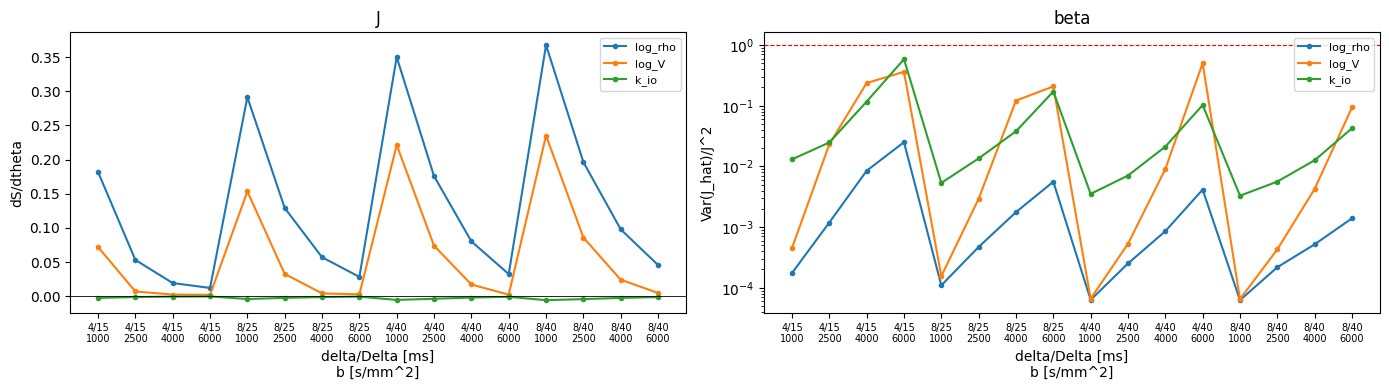

In [33]:
# ---- J / beta by acquisition column ----------------------------------------
x = np.arange(len(R["b"]))
labels = [f"{d:.0f}/{D:.0f}\n{b:.0f}" for d, D, b in zip(R["delta"], R["Delta"], R["b"])]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for j, n in enumerate(PARAMETER_ORDER):
    ax[0].plot(x, R["J"][:, j], "o-", ms=3, label=n)
    ax[1].semilogy(x, R["beta"][:, j], "o-", ms=3, label=n)
ax[0].axhline(0, c="k", lw=.6); ax[1].axhline(1, c="r", ls="--", lw=.8)
ax[0].set(ylabel="dS/dtheta", title="J")
ax[1].set(ylabel="Var(J_hat)/J^2", title="beta")
for a in ax:
    a.set_xticks(x); a.set_xticklabels(labels, fontsize=7)
    a.set_xlabel("delta/Delta [ms]\nb [s/mm^2]"); a.legend(fontsize=8)
fig.tight_layout()


Old single-timing sweep omitted in the multi-timing version. The acquisition is controlled by `ACQUISITIONS` above.


Old single-timing sweep omitted in the multi-timing version. The acquisition is controlled by `ACQUISITIONS` above.


Old single-timing sweep omitted in the multi-timing version. The acquisition is controlled by `ACQUISITIONS` above.
